In [ ]:
%pip install markdown

In [ ]:
%pip install matplotlib

In [17]:
import numpy as np
import markdown
from scipy.linalg import solve_discrete_lyapunov


def simulate_state_space(A, C, T, x0, G = None, seed = None):
    """
    Simulates a state-space model defined by the equations:
        x_{t+1} = A * x_t + C * w_t
        y_t = G * x_t (if G is provided)
    """
    
    rng = np.random.default_rng(seed)
    
    A = np.asarray(A)
    C = np.asarray(C)
    
    n = A.shape[0]
    q = C.shape[1]
    
    x = np.empty((T + 1, n))
    x[0] = x0
    
    for t in range(T):
        w = rng.standard_normal(q)
        x[t + 1] = A @ x[t] + C @ w
        
    if G is None:
        return x
    
    y = x @ G.T
    
    return x, y

def is_stab(A):
    """
    Checks if the system defined by matrix A is stable.
    A system is stable if all eigenvalues of A have absolute values less than 1.
    """
    eigenvalues = np.linalg.eigvals(A)
    return np.max(np.abs(eigenvalues)) < 1

def stationary_covariance(A, C):
    """
    Computes the stationary covariance matrix of the state vector x_t
    for a stable system defined by matrices A and C, where the stationary covariance
    is defined as the solution to the discrete Lyapunov equation:
        Sigma = A * Sigma * A' + C * C'
    """
    
    Q = C @ C.T
    
    return solve_discrete_lyapunov(A, Q)

def autocovariance(A, Sigma, lag):
    """
    Computes the autocovariance of the state vector x_t at a given lag for a stable system,
    where Sigma is the stationary covariance matrix of x_t, and autocovariance is defined as:
        Gamma(lag) = A^lag * Sigma
    """
    return np.linalg.matrix_power(A, lag) @ Sigma

def irf(A, C, G = None, horizon = 20):
    """
    Computes the impulse response function (IRF) of the state-space model defined by matrices A, C, and G.
    The IRF describes how the system responds to a one-time impulse in the input over a specified horizon.
    """
    
    if G is None:
        G = np.eye(A.shape[0])
        
    responses = []
    
    for j in range(horizon + 1):
        Aj = np.linalg.matrix_power(A, j)
        responses.append(G @ Aj @ C)
    
    return np.array(responses)

def forecast_state(A, x_t, horizon):
    """
    Forecasts the state vector x_{t+h} given the current state x_t and the system matrix A.
    The forecast is computed as:
        x_{t+h} = A^h * x_t
    """
    return np.linalg.matrix_power(A, horizon) @ x_t

def discounted_forecast(A, G, x_t, beta):
    
    n = A.shape[0]
    
    resolvent = np.linalg.solve(
        np.eye(n) - beta * A,
        x_t
    )
    
    return G @ resolvent
    


# A Macroeconomic Application of a Linear State-Space Model

A useful way to understand these functions is to stop thinking of $A$, $C$, $G$ as abstract matrices and instead imagine that you are a central-bank economist studying a small linearized business-cycle model.

This is exactly the type of object Chapter 2 of Ljungqvist and Sargent is preparing you for: it introduces stochastic linear difference equations, their first and second moments, impulse responses, and prediction/discounting. More generally, the book emphasizes that recursive methods describe the economy through a **state today, a law of motion into tomorrow, and variables that are functions of the state**.

Suppose our state vector is

$$
x_t =
\begin{bmatrix}
\tilde{y}_t \\
\tilde{\pi}_t
\end{bmatrix},
$$

where

- $\tilde{y}_t$ = output gap, in percentage points;
- $\tilde{\pi}_t$ = inflation gap, i.e. inflation minus the central bank's target, in percentage points.

So, for example,

$$
x_t =
\begin{bmatrix}
-2 \\
1
\end{bmatrix}
$$

means that output is 2% below potential while inflation is 1 percentage point above target: a mild stagflationary situation.

Now consider this model:

In [19]:
A = np.array([
    [0.70, -0.20],
    [0.15,  0.75]
])

C = np.array([
    [0.50, 0.00],
    [0.10, 0.40]
])

G = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 1.0]
])

with

$$
x_{t+1} = A x_t + C w_t,
$$

and

$$
w_t =
\begin{bmatrix}
\varepsilon_t^d \\
\varepsilon_t^s
\end{bmatrix},
$$

where $\varepsilon_t^d$ is a demand shock and $\varepsilon_t^s$ is a supply/cost-push shock.

The whole model can therefore be visualized as

$$
\boxed{
\text{Today's economy}
\quad
x_t
\longrightarrow
x_{t+1}
\longrightarrow
\text{economic variables we care about}
}
$$

---

## 1. `simulate_state_space`: generate an artificial macroeconomic history

Your first function is

`simulate_state_space(A, C, T, x0, G=None, seed=None)`

Economically, it answers:

> Starting from today's economic conditions, what might one possible future path of the economy look like if random demand and supply shocks keep arriving?

Suppose the economy initially starts exactly at equilibrium:

In [ ]:
x = np.array([0.0, 0.0])

so that

$$
\tilde{y}_0 = 0,
\qquad
\tilde{\pi}_0 = 0.
$$

Run

In [23]:
x, y = simulate_state_space(
    A, C,
    T=20,
    x0=x0,
    G=G,
    seed=42
)


Every period Python draws

$$
w_t \sim N(0,I).
$$

Then, for example,

$$
x_{t+1}
=
\begin{bmatrix}
0.70 & -0.20 \\
0.15 & 0.75
\end{bmatrix}
x_t
+
\begin{bmatrix}
0.50 & 0 \\
0.10 & 0.40
\end{bmatrix}
\begin{bmatrix}
\varepsilon_t^d \\
\varepsilon_t^s
\end{bmatrix}.
$$

### Economic interpretation of $A$

Look at the first equation:

$$
\tilde{y}_{t+1}
=
0.70\tilde{y}_t
-
0.20\tilde{\pi}_t
+
0.50\varepsilon_t^d.
$$

It says:

- 70% of today's output gap carries into next period;
- inflation above target depresses subsequent economic activity;
- demand shocks directly move output.

The second equation is

$$
\tilde{\pi}_{t+1}
=
0.15\tilde{y}_t
+
0.75\tilde{\pi}_t
+
0.10\varepsilon_t^d
+
0.40\varepsilon_t^s.
$$

So:

- inflation is persistent;
- a positive output gap creates inflationary pressure;
- demand shocks also increase inflation;
- supply shocks predominantly move inflation.

This is not meant to be a fully structural New Keynesian model. It is a **stylized linear approximation** designed to give the matrices a concrete macroeconomic meaning.

### What does $G$ do?

You specified

$$
y_t = Gx_t.
$$

With our $G$,

$$
G =
\begin{bmatrix}
1 & 0 \\
0 & 1 \\
0.5 & 1
\end{bmatrix}.
$$

Therefore

$$
y_t =
\begin{bmatrix}
\tilde{y}_t \\
\tilde{\pi}_t \\
0.5\tilde{y}_t+\tilde{\pi}_t
\end{bmatrix}.
$$

The first two observables are simply the output and inflation gaps. The third could be interpreted as a crude **macroeconomic pressure index** combining overheating and inflation.

This illustrates an important distinction:

$$
\boxed{x_t = \text{state of the economy}}
$$

versus

$$
\boxed{y_t = \text{variables constructed/observed from the state}}.
$$

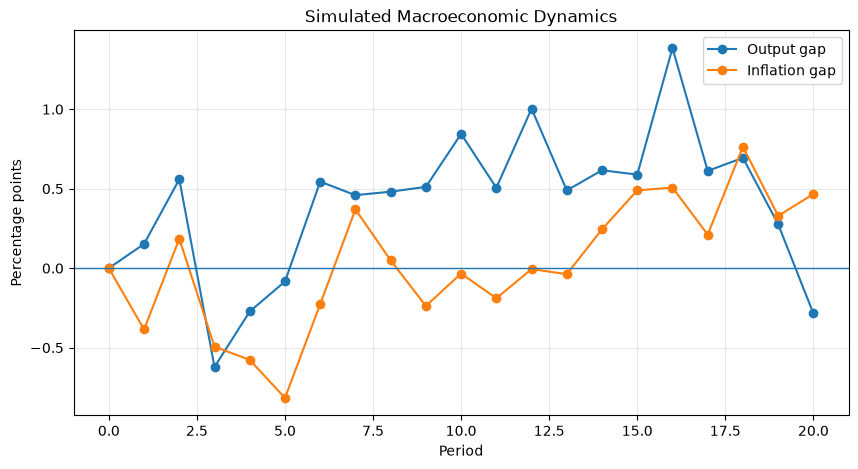

In [38]:
import matplotlib.pyplot as plt

time = np.arange(x.shape[0])

plt.figure(figsize=(10, 5))

plt.plot(
    time,
    x[:, 0],
    marker="o",
    label="Output gap"
)

plt.plot(
    time,
    x[:, 1],
    marker="o",
    label="Inflation gap"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Period")
plt.ylabel("Percentage points")
plt.title("Simulated Macroeconomic Dynamics")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Visualizing the simulated economy

The graph shows one possible realization of the stochastic economy.

The two lines represent

$$
\tilde{y}_t
\qquad\text{and}\qquad
\tilde{\pi}_t,
$$

the output gap and inflation gap.

Even though the economy is stable, neither variable remains at zero because new random shocks arrive every period.

This illustrates the distinction between **stability** and the absence of fluctuations.

A stable stochastic economy can continue fluctuating indefinitely:

$$
x_{t+1}=Ax_t+Cw_t,
$$

because the effects of past shocks gradually disappear while new shocks continuously enter the system.

The horizontal line at zero represents macroeconomic equilibrium:

$$
\tilde{y}_t=0,
\qquad
\tilde{\pi}_t=0.
$$

Values above or below zero therefore represent periods in which output is respectively above or below potential and inflation is above or below the central bank's target.

# 2. `is_stab(A)`: will shocks eventually die out?

Now suppose the central bank asks:

> If no additional shocks arrive, will the economy naturally return toward equilibrium, or will deviations explode?

That is exactly what

In [ ]:
is_stab(A)

checks.

The eigenvalues of our $A$ are approximately

$$
\lambda_{1,2}
=
0.725 \pm 0.171i.
$$

Their modulus is about

$$
|\lambda| \approx 0.745 < 1.
$$

Therefore:

In [ ]:
is_stab(A)
# True

The economic meaning is crucial.

Imagine a recession occurs today. If all future shocks are zero,

$$
x_{t+1} = A x_t.
$$

Then

$$
x_{t+h} = A^h x_t.
$$

Since

$$
A^h \rightarrow 0
$$

as $h \rightarrow \infty$,

$$
x_{t+h}
\rightarrow
\begin{bmatrix}
0 \\
0
\end{bmatrix}.
$$

In our context:

$$
\boxed{
\text{output eventually returns to potential and inflation returns to target.}
}
$$

This does **not** mean the actual simulated economy will stay at zero, because new shocks continuously arrive. It means the effects of any particular shock eventually disappear.

That distinction is very important:

$$
\text{stable} \neq \text{constant}.
$$

A stable stochastic economy can fluctuate forever because it keeps receiving shocks.

# 3. `stationary_covariance`: how volatile is the economy in the long run?

Once we know that the system is stable, we can ask:

> If this economy runs for a very long time under these shocks, how volatile will output and inflation typically be?

Your function computes

In [ ]:
Sigma = stationary_covariance(A, C)
Sigma

where

$$
\Sigma = A\Sigma A' + CC'.
$$

For our example,

$$
\Sigma
\approx
\begin{bmatrix}
0.4884 & 0.0674 \\
0.0674 & 0.4483
\end{bmatrix}.
$$

Remember that

$$
\Sigma
=
\operatorname{Var}(x_t).
$$

So the diagonal elements are variances:

$$
\operatorname{Var}(\tilde{y}_t)=0.4884,
$$

$$
\operatorname{Var}(\tilde{\pi}_t)=0.4483.
$$

Hence the long-run standard deviations are approximately

$$
\sigma_y=\sqrt{0.4884}\approx0.699,
$$

and

$$
\sigma_\pi=\sqrt{0.4483}\approx0.670.
$$

So, under this calibration, a typical fluctuation is roughly:

- output gap: ±0.7 percentage points;
- inflation gap: ±0.67 percentage points.

The off-diagonal element

$$
0.0674
$$

is

$$
\operatorname{Cov}(\tilde{y}_t,\tilde{\pi}_t).
$$

It is positive, so periods with unusually high output tend, on average, also to have somewhat unusually high inflation.

This matrix therefore summarizes the **long-run business-cycle variability implied jointly by the propagation mechanism $A$ and shock sizes $C$**.

And the Lyapunov equation has a beautiful economic interpretation:

$$
\underbrace{\Sigma}_{\text{total long-run uncertainty}}
=
\underbrace{A\Sigma A'}_{\text{uncertainty inherited from the past}}
+
\underbrace{CC'}_{\text{new uncertainty arriving today}}.
$$

That is probably the most intuitive way to remember it.

# 4. `autocovariance`: how persistent are recessions and inflation episodes?

Suppose policymakers now ask:

> If output is weak today, how much does that tell us about output several quarters from now?

This is what autocovariance measures.

Your function calculates

In [27]:
Gamma_1 = autocovariance(A, Sigma, lag=1)
Gamma_1

array([[ 0.32838038, -0.0425014 ],
       [ 0.12379074,  0.34636254]])

with

$$
\Gamma(k)=A^k\Sigma.
$$

At lag one we obtain approximately

$$
\Gamma(1)=
\begin{bmatrix}
0.3284 & -0.0425 \\
0.1238 & 0.3464
\end{bmatrix}.
$$

For example,

$$
\Gamma_{11}(1)
=
\operatorname{Cov}(\tilde{y}_{t+1},\tilde{y}_t)
\approx0.328.
$$

That says output gaps have substantial persistence.

A recession today makes a recession next period more likely.

Meanwhile,

$$
\Gamma_{22}(1)
=
\operatorname{Cov}(\tilde{\pi}_{t+1},\tilde{\pi}_t)
\approx0.346.
$$

So inflation deviations are persistent too.

At lag four,

$$
\Gamma(4)\approx
\begin{bmatrix}
0.053 & -0.119 \\
0.120 & 0.113
\end{bmatrix}.
$$

The relationships have become much weaker.

That is the statistical counterpart of the intuition:

$$
\boxed{\text{economic shocks have memory, but that memory fades.}}
$$

This is why macroeconomists care so much about persistence. Two economies could have identical current inflation but radically different implications if inflation is highly persistent in one and transitory in the other.

In [28]:
Gamma_4 = autocovariance(A, Sigma, lag=4)
Gamma_4

array([[ 0.0531407 , -0.11903584],
       [ 0.12027932,  0.11339613]])

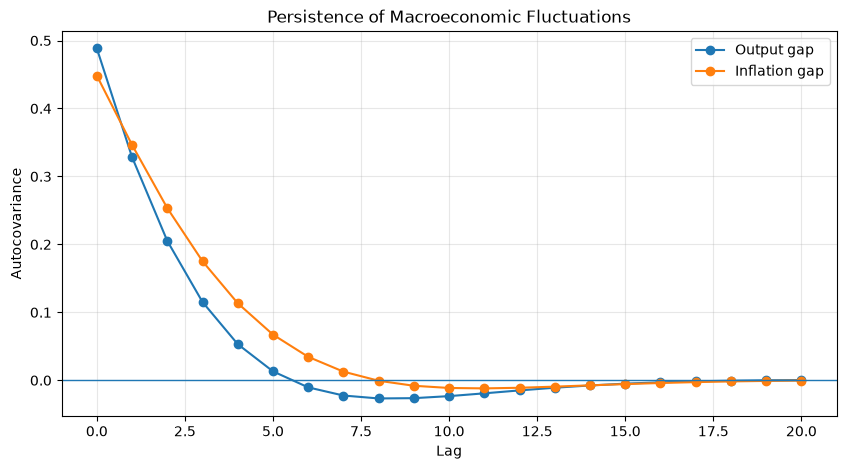

In [37]:
max_lag = 20

lags = np.arange(max_lag + 1)

output_autocov = np.array([
    autocovariance(A, Sigma, lag)[0, 0]
    for lag in lags
])

inflation_autocov = np.array([
    autocovariance(A, Sigma, lag)[1, 1]
    for lag in lags
])

plt.figure(figsize=(10, 5))

plt.plot(
    lags,
    output_autocov,
    marker="o",
    label="Output gap"
)

plt.plot(
    lags,
    inflation_autocov,
    marker="o",
    label="Inflation gap"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Lag")
plt.ylabel("Autocovariance")
plt.title("Persistence of Macroeconomic Fluctuations")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Visualizing persistence

The autocovariance functions show how information about current macroeconomic conditions becomes less informative as we look further into the future.

For the output gap,

$$
\Gamma_{11}(k)
=
\operatorname{Cov}
\left(
\tilde{y}_{t+k},
\tilde{y}_t
\right),
$$

while for inflation,

$$
\Gamma_{22}(k)
=
\operatorname{Cov}
\left(
\tilde{\pi}_{t+k},
\tilde{\pi}_t
\right).
$$

Because the system is stable, the effect of today's economic conditions progressively fades as the lag increases.

Thus,

$$
A^k \rightarrow 0
$$

implies that

$$
\Gamma(k)
=
A^k\Sigma
\rightarrow 0.
$$

The graph therefore gives a visual representation of the idea that

$$
\boxed{\text{economic shocks have memory, but that memory fades.}}
$$

A slowly declining curve would indicate strong persistence, while a rapidly declining curve would indicate that disturbances are mostly transitory.

# 5. `irf`: what happens after one specific macroeconomic shock?

This is probably the most economically intuitive function in your set.

In [ ]:
responses = irf(A, C, G, horizon=20)
responses

asks:

> Suppose exactly one shock occurs today and then no more shocks occur. What happens to the economy afterward?

Mathematically,

$$
IRF(j)=GA^jC.
$$

There are two columns because our $C$ contains two shocks:

$$
C=
\begin{bmatrix}
0.50 & 0 \\
0.10 & 0.40
\end{bmatrix}.
$$

Column 1 = demand shock.

Column 2 = supply shock.

---

### Positive demand shock

Suppose

$$
w_0=
\begin{bmatrix}
1 \\
0
\end{bmatrix}.
$$

At impact:

$$
Cw_0=
\begin{bmatrix}
0.50 \\
0.10
\end{bmatrix}.
$$

So a one-standard-deviation positive demand shock causes:

$$
\tilde{y}_1=+0.50
$$

and

$$
\tilde{\pi}_1=+0.10.
$$

One period later, its remaining effect is approximately

$$
A
\begin{bmatrix}
0.50 \\
0.10
\end{bmatrix}
=
\begin{bmatrix}
0.33 \\
0.15
\end{bmatrix}.
$$

Two periods later:

$$
\begin{bmatrix}
0.201 \\
0.162
\end{bmatrix}.
$$

Three:

$$
\begin{bmatrix}
0.108 \\
0.152
\end{bmatrix}.
$$

So the story is:

$$
\text{demand boom}
\rightarrow
\text{large immediate output response}
\rightarrow
\text{inflation builds}
\rightarrow
\text{both eventually disappear}.
$$

That is exactly what an impulse-response graph would visualize.

---

### Positive cost-push shock

Now instead let

$$
w_0=
\begin{bmatrix}
0 \\
1
\end{bmatrix}.
$$

Impact:

$$
Cw_0=
\begin{bmatrix}
0 \\
0.40
\end{bmatrix}.
$$

So there is initially:

- no direct output effect;
- +0.40 inflation gap.

But next period,

$$
A
\begin{bmatrix}
0 \\
0.4
\end{bmatrix}
=
\begin{bmatrix}
-0.08 \\
0.30
\end{bmatrix}.
$$

Now we obtain something resembling stagflation:

$$
\boxed{
\text{inflation above target + output below potential}.
}
$$

The sequence for the output gap is approximately

$$
0,\;-0.08,\;-0.116,\;-0.124,\;-0.115,\ldots
$$

while inflation gradually falls from

$$
0.40,\;0.30,\;0.213,\;0.142,\;0.088,\ldots
$$

This is why IRFs are so common in macroeconomics: they turn a matrix model into an economic story.

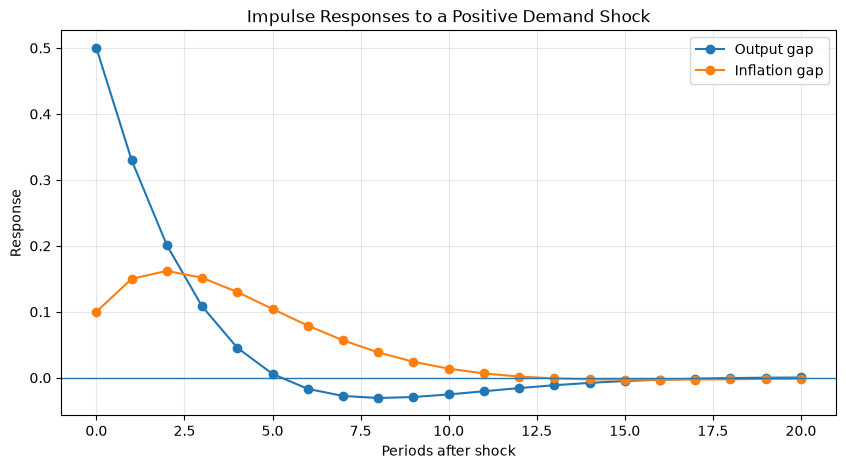

In [39]:
horizon = np.arange(responses.shape[0])

plt.figure(figsize=(10, 5))

plt.plot(
    horizon,
    responses[:, 0, 0],
    marker="o",
    label="Output gap"
)

plt.plot(
    horizon,
    responses[:, 1, 0],
    marker="o",
    label="Inflation gap"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Periods after shock")
plt.ylabel("Response")
plt.title("Impulse Responses to a Positive Demand Shock")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Impulse response to a positive demand shock

The graph traces the dynamic consequences of a one-time positive demand shock.

At impact,

$$
C
\begin{bmatrix}
1\\
0
\end{bmatrix}
=
\begin{bmatrix}
0.50\\
0.10
\end{bmatrix},
$$

so output initially rises substantially while inflation rises more moderately.

After the initial shock, no additional disturbances occur. The subsequent path therefore reflects only the internal propagation mechanism of the economy:

$$
A^jC.
$$

The initial increase in demand raises output immediately, but the stronger economy subsequently generates inflationary pressure.

As time passes, stability implies

$$
A^j\rightarrow0,
$$

so both responses eventually return toward zero.

The graph therefore illustrates the sequence

$$
\text{demand boom}
\rightarrow
\text{higher output}
\rightarrow
\text{inflationary pressure}
\rightarrow
\text{return toward equilibrium}.
$$

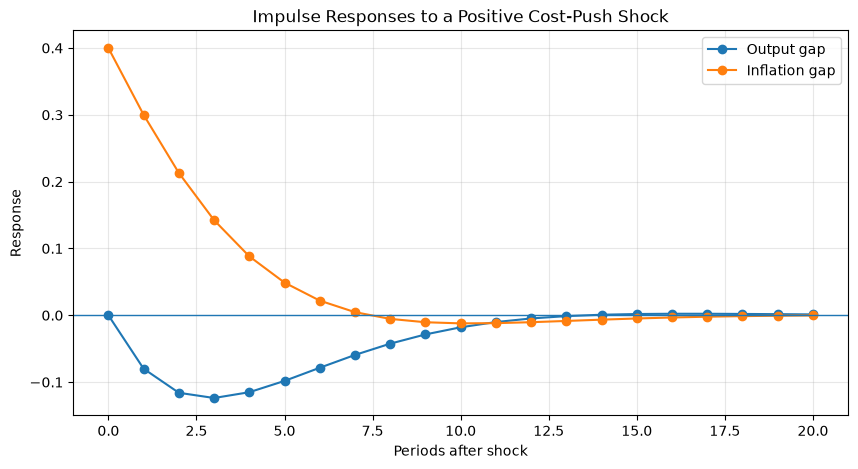

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizon,
    responses[:, 0, 1],
    marker="o",
    label="Output gap"
)

plt.plot(
    horizon,
    responses[:, 1, 1],
    marker="o",
    label="Inflation gap"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Periods after shock")
plt.ylabel("Response")
plt.title("Impulse Responses to a Positive Cost-Push Shock")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Impulse response to a positive cost-push shock

The second shock has a very different economic interpretation.

At impact,

$$
C
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
\begin{bmatrix}
0\\
0.40
\end{bmatrix}.
$$

Thus, the supply shock initially raises inflation without directly increasing output.

One period later,

$$
A
\begin{bmatrix}
0\\
0.40
\end{bmatrix}
=
\begin{bmatrix}
-0.08\\
0.30
\end{bmatrix}.
$$

The economy therefore moves into a situation resembling **stagflation**:

$$
\boxed{
\tilde{y}_t<0
\qquad\text{and}\qquad
\tilde{\pi}_t>0
}
$$

with output below potential while inflation remains above target.

The graph makes the difference between demand and supply shocks particularly clear.

A demand shock initially moves output and inflation in the same direction, whereas a cost-push shock generates an inflation-output trade-off.

# 6. `forecast_state`: given today's economy, where do we expect it to be?

Now imagine actual data tell us:

$$
x_t=
\begin{bmatrix}
-2 \\
1
\end{bmatrix}.
$$

Output is 2% below potential and inflation is 1 percentage point above target.

We ask:

> Assuming future shocks have mean zero, what do we expect the economy to look like four periods from now?

Run:

In [30]:
forecast_state(
    A,
    np.array([-2, 1]),
    horizon=4
)

array([-0.584875  , -0.21125625])

which computes

$$
E_t[x_{t+4}]
=
A^4x_t.
$$

The result is approximately

$$
\begin{bmatrix}
-0.585 \\
-0.211
\end{bmatrix}.
$$

So the model predicts that four periods ahead:

- output remains about 0.59% below potential;
- inflation is approximately 0.21 percentage points below target.

Why do shocks disappear from the forecasting formula?

Because

$$
E_t[w_{t+j}]=0.
$$

Starting from

$$
x_{t+1}=Ax_t+Cw_t,
$$

taking expectations gives

$$
E_t[x_{t+1}]
=
Ax_t.
$$

And recursively,

$$
\boxed{
E_t[x_{t+h}] = A^h x_t.
}
$$

Notice the difference between this and simulation:

### Simulation


In [ ]:
simulate_state_space()

asks:

> What is one possible future?

It includes random future shocks.

### Forecast

In [ ]:
forecast_state()

asks:

> What is the conditional mean future?

It sets future shocks to their expected value, zero.

This distinction is fundamental.

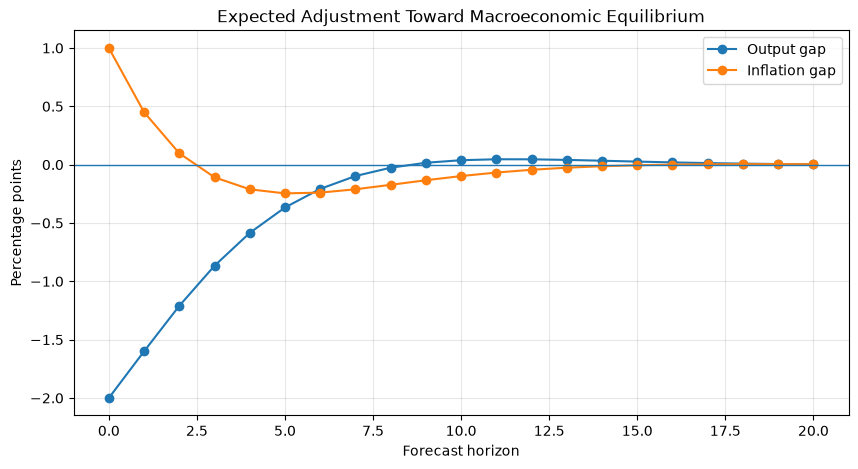

In [42]:
forecast_horizon = 20
x_today = np.array([-2, 1])

forecast_path = np.array([
    forecast_state(A, x_today, h)
    for h in range(forecast_horizon + 1)
])

horizons = np.arange(forecast_horizon + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    horizons,
    forecast_path[:, 0],
    marker="o",
    label="Output gap"
)

plt.plot(
    horizons,
    forecast_path[:, 1],
    marker="o",
    label="Inflation gap"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Forecast horizon")
plt.ylabel("Percentage points")
plt.title("Expected Adjustment Toward Macroeconomic Equilibrium")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Visualizing the conditional forecast

The graph shows the expected path of the economy conditional on today's state

$$
x_t=
\begin{bmatrix}
-2\\
1
\end{bmatrix}.
$$

At the initial date, output is substantially below potential while inflation is above target.

For every forecast horizon $h$,

$$
E_t[x_{t+h}]
=
A^h x_t.
$$

No future random shocks appear in the graph because

$$
E_t[w_{t+j}]=0.
$$

The figure therefore isolates the model's expected adjustment mechanism.

As the forecast horizon becomes longer,

$$
A^h x_t \rightarrow 0,
$$

and consequently

$$
E_t[\tilde{y}_{t+h}] \rightarrow 0,
$$

and

$$
E_t[\tilde{\pi}_{t+h}] \rightarrow 0.
$$

Economically, the system gradually returns toward

$$
\boxed{
\text{output at potential}
\qquad\text{and}\qquad
\text{inflation at target}.
}
$$

Notice that this graph is fundamentally different from the simulated path.

The simulation contains future random shocks:

$$
x_{t+1}=Ax_t+Cw_t,
$$

while the forecast graph represents the conditional mean:

$$
E_t[x_{t+h}]=A^h x_t.
$$

In [ ]:
x_sim, _ = simulate_state_space(
    A=A,
    C=C,
    T=20,
    x0=x_today,
    G=G,
    seed=7
)

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizons,
    forecast_path[:, 0],
    linewidth=2,
    label="Expected output gap"
)

plt.plot(
    horizons,
    x_sim[:, 0],
    marker="o",
    label="Simulated output gap"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Period")
plt.ylabel("Output gap")
plt.title("Expected vs Simulated Output Dynamics")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Forecast versus realized economic dynamics

This comparison highlights one of the most important distinctions in stochastic macroeconomic models.

The expected path is

$$
E_t[x_{t+h}]
=
A^h x_t.
$$

It describes the mean evolution of the economy conditional on the information available today.

The simulated path, instead, follows

$$
x_{t+1}
=
Ax_t+Cw_t,
$$

and therefore incorporates new shocks that could not have been known at time $t$.

Consequently, the realized economy can temporarily move far away from the forecast even when the model itself is correctly specified.

In other words,

$$
\boxed{
\text{forecast}
=
\text{expected future}
}
$$

whereas

$$
\boxed{
\text{simulation}
=
\text{one possible realized future}.
}
$$

This is why macroeconomic forecasts should not be interpreted as exact predictions of future outcomes. They represent conditional expectations around which actual outcomes fluctuate because of future innovations.

# 7. `discounted_forecast`: summarize the whole expected future path

Finally, suppose the central bank does not care only about inflation next quarter or four quarters ahead. It cares about the **entire expected future sequence**.

Your function

In [ ]:
discounted_forecast(A, G, x_t, beta)

computes

$$
G(I-\beta A)^{-1}x_t.
$$

Why?

Because

$$
(I-\beta A)^{-1}
=
I+\beta A+\beta^2A^2+\beta^3A^3+\cdots.
$$

Therefore,

$$
G(I-\beta A)^{-1}x_t
=
Gx_t
+
\beta GAx_t
+
\beta^2GA^2x_t
+\cdots.
$$

In other words,

$$
\boxed{
\sum_{j=0}^{\infty}
\beta^j E_t[y_{t+j}]
}
$$

is being calculated.

This is directly connected with the matrix geometric-series logic used repeatedly in recursive macroeconomics. For example, the text derives discounted values using

$$
I+\beta P+\beta^2P^2+\cdots=(I-\beta P)^{-1}
$$

in the Markov-chain setting.

Suppose again

$$
x_t=
\begin{bmatrix}
-2 \\
1
\end{bmatrix}
$$

and use

$$
\beta=0.95.
$$

Then

In [33]:
discounted_forecast(
    A, G,
    np.array([-2, 1]),
    beta=0.95
)

array([-6.19997974,  0.40522743, -2.69476244])

gives approximately

$$
\begin{bmatrix}
-6.20 \\
0.405 \\
-2.695
\end{bmatrix}.
$$

Interpret the first entry:

$$
-6.20
=
\sum_{j=0}^{\infty}
0.95^j E_t[\tilde{y}_{t+j}].
$$

It does **not** mean output will be 6.2% below potential in some future period.

Instead it means:

> The discounted sum of all expected future output gaps, starting from today's situation, is $-6.20$.

Likewise,

$$
0.405
=
\sum_{j=0}^{\infty}
0.95^j E_t[\tilde{\pi}_{t+j}].
$$

So this compresses an entire future path into one number.

This type of expression becomes extremely important later in macroeconomics because agents maximize things like

$$
E_t\sum_{j=0}^{\infty}\beta^j u(c_{t+j}),
$$

governments evaluate discounted future costs, and asset prices depend on discounted future payoffs.

# Putting all seven functions into one economic workflow

Imagine you work at the ECB and are given this small model.

You would naturally proceed in this order:

$$
\boxed{x_{t+1}=Ax_t+Cw_t}
$$

First, ask whether the model is economically well behaved:

In [ ]:
is_stab(A)

> Do deviations eventually decay?

Then characterize its long-run stochastic behavior:

In [ ]:
Sigma = stationary_covariance(A, C)

> How volatile are output and inflation in normal times?

and

In [ ]:
autocovariance(A, Sigma, 1)

> How persistent are those fluctuations?

Then conduct policy/economic experiments:

In [ ]:
irf(A, C, G)

> What happens after a demand shock or a supply shock?

Given actual current conditions:

In [ ]:
x_today = np.array([-2, 1])

forecast_state(A, x_today, 4)

> Where do we expect the economy to be one year from now?

If you care about the whole future rather than one horizon:

In [ ]:
discounted_forecast(
    A,
    G,
    x_today,
    beta=0.95
)

> What is the discounted cumulative effect of today's economic conditions?

And finally:

In [ ]:
simulate_state_space(
    A,
    C,
    100,
    x0,
    G,
    seed=42
)

> Generate a possible 100-quarter artificial history of this economy and see what business cycles generated by the model actually look like.

So the functions are not really seven unrelated mathematical tricks. They all interrogate the **same dynamic macroeconomic model from different angles**:

$$
\boxed{
\begin{array}{ll}
\texttt{simulate\_state\_space} &
\text{What possible histories can occur?}
\\[2mm]

\texttt{is\_stab} &
\text{Do disturbances eventually die out?}
\\[2mm]

\texttt{stationary\_covariance} &
\text{How volatile is the economy in the long run?}
\\[2mm]

\texttt{autocovariance} &
\text{How persistent are fluctuations?}
\\[2mm]

\texttt{irf} &
\text{What does one particular shock do?}
\\[2mm]

\texttt{forecast\_state} &
\text{Where do we expect the economy to be at } t+h?
\\[2mm]

\texttt{discounted\_forecast} &
\text{What is the value of the entire expected future path?}
\end{array}
}
$$

The conceptual leap is that **$A$ is the propagation mechanism of the economy, $C$ tells you how shocks enter it, $x_t$ tells you where the economy is now, and $G$ tells you which economic variables you want to extract from that state**. Once you see it that way, essentially every function you wrote is asking a different economically meaningful question about the same system.